This notebook covers t-test,p-values

In [1]:
import numpy as np
from scipy import stats

In [2]:
#One-sample t-test

np.random.seed(42)

x = np.random.normal(loc=52, scale=5, size=30)
mu0 = 50

#manual calculation
n = len(x)
x_bar = np.mean(x)
s = np.std(x, ddof=1)

t_manual = (x_bar - mu0) / (s / np.sqrt(n))

# two-tailed p-value
p_manual = 2 * stats.t.sf(np.abs(t_manual), df=n-1)

print("Manual t:", t_manual)
print("Manual p:", p_manual)

#scipy
t_scipy, p_scipy = stats.ttest_1samp(x, mu0)

print("SciPy t:", t_scipy)
print("SciPy p:", p_scipy)

Manual t: 1.2892877260308195
Manual p: 0.20748712034193556
SciPy t: 1.2892877260308195
SciPy p: 0.20748712034193556


In [6]:
#Welch vs classical t-test
np.random.seed(0)

a = np.random.normal(50, 10, 40)
b = np.random.normal(55, 20, 35)

# assuming equal variance
t_eq, p_eq = stats.ttest_ind(a, b, equal_var=True)

# Welch test
t_welch, p_welch = stats.ttest_ind(a, b, equal_var=False)

print("Equal var p:", p_eq)
print("Welch p:", p_welch)

Equal var p: 0.11211597706620775
Welch p: 0.12433551895657141


In [4]:
#permutations usage to calculate p

from scipy.stats import ttest_ind, PermutationMethod

res = ttest_ind(a, b, method=PermutationMethod(n_resamples=10000))

print(res)

TtestResult(statistic=np.float64(1.6081642453521185), pvalue=np.float64(0.10978902109789021), df=np.float64(73.0))


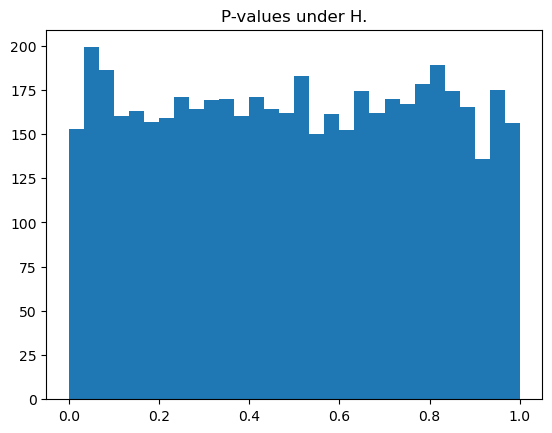

In [3]:
#Simulating p-value distribution
## simulatingunder H.(naught)
p_values = []

for _ in range(5000):
    x = np.random.normal(0, 1, 30)
    y = np.random.normal(0, 1, 30)
    _, p = stats.ttest_ind(x, y)
    p_values.append(p)

import matplotlib.pyplot as plt
plt.hist(p_values, bins=30)
plt.title("P-values under H.")
plt.show()

In [4]:
#power & type II error
## simulate power
rejections = 0
alpha = 0.05

for _ in range(5000):
    x = np.random.normal(0, 1, 30)
    y = np.random.normal(0.5, 1, 30)
    _, p = stats.ttest_ind(x, y)

    if p < alpha:
        rejections += 1

print("Estimated power:", rejections / 5000)

Estimated power: 0.4736


In [7]:
#checking normality and equality of variance using shapiro-wilk & levene tests
# normality test
print(stats.shapiro(a))
print(stats.shapiro(b))

# variance equality
print(stats.levene(a, b))

ShapiroResult(statistic=np.float64(0.9782683143715208), pvalue=np.float64(0.6254530482826594))
ShapiroResult(statistic=np.float64(0.9727920096914614), pvalue=np.float64(0.5243900342532767))
LeveneResult(statistic=np.float64(7.972109961136193), pvalue=np.float64(0.006119024791031644))
